# SGI-2.11 — Which model is Marvel?

**Marvel Superstars**, week 2. The week walked through three classic network models — the random
network, the Watts–Strogatz small world and Barabási–Albert preferential attachment — and one idea
that turns a model into a test: the **null model**.

**The question.** Build each model at Marvel's size and put it next to the real network. Which of
Marvel's properties does each model reproduce? And which of them survive when we keep every
character's exact degree but scramble who links to whom?

**What we measure.** Four numbers per network, each from a different part of week 2: average
clustering $C$, average distance $\langle d \rangle$, the biggest hub, and the strength of the
friendship paradox. Every model is generated 50 times, so every model number is a mean with a spread.

Figures export to `Figures/Week2/`; every number quoted in the post lands in `stats.json`.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from matplotlib.ticker import FuncFormatter, MaxNLocator
from scipy.stats import poisson

DATA = Path("../../Data/Week1")          # week 2 has no new release: same frozen snapshot
FIGDIR = Path("../../Figures/Week2")     # written straight to where the post reads them
FIGDIR.mkdir(parents=True, exist_ok=True)

DARK = {"figure.facecolor": "#161616", "axes.facecolor": "#161616",
        "axes.edgecolor": "#3a3a3a", "axes.labelcolor": "#8a8a8a",
        "text.color": "#e8e8e8", "xtick.color": "#8a8a8a", "ytick.color": "#8a8a8a",
        "grid.color": "#2e2e2e", "savefig.facecolor": "#161616", "figure.dpi": 130}
MARVEL_C, RANDOM_C, WS_C, BA_C, SHUFFLE_C = "#4f7fd4", "#9a9a9a", "#6fc3a0", "#e0913c", "#c678dd"

RUNS = 50           # networks per model: every model number is a mean with a spread
STATS = {}          # every number quoted in the post lands here, then to stats.json


def save(fig, name):
    fig.savefig(FIGDIR / f"{name}.png", bbox_inches="tight", dpi=150)
    print(f"  wrote Figures/Week2/{name}.png")


def style(ax):
    ax.grid(alpha=.3, lw=.5)
    ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)


print(f"python {sys.version.split()[0]} | networkx {nx.__version__} | "
      f"matplotlib {plt.matplotlib.__version__}")

python 3.14.6 | networkx 3.6.1 | matplotlib 3.11.0


## 1. Load: Marvel's giant component

The same frozen snapshot as week 1 — week 2 has no new data release. Two representation choices,
both made before measuring anything:

- **Undirected.** All three models are undirected, so a link here means the two articles are
  connected in either direction.
- **Giant component only: 277 of the 303 characters.** Distance is undefined between characters in
  different components (week 1's 17 isolates and nine-character island), and every model below
  produces one connected network. The course explorables use the same 277.

In [2]:
nodes = pd.read_csv(DATA / "week1_nodes.tsv", sep="\t", comment="#",
                    quoting=3)  # QUOTE_NONE: blurbs contain unescaped "quotes"
edges = pd.read_csv(DATA / "week1_edges.tsv", sep="\t", comment="#",
                    names=["source", "target"])

G = nx.DiGraph()
G.add_nodes_from(nodes.node_id)          # nodes first, or the 17 isolates silently vanish
G.add_edges_from(edges.itertuples(index=False))
U = G.to_undirected()
M = U.subgraph(max(nx.connected_components(U), key=len)).copy()
NAME = dict(zip(nodes.node_id, nodes.name))

n, m = M.number_of_nodes(), M.number_of_edges()
N = G.number_of_nodes()
STATS.update(n=n, m=m, mean_degree=round(2 * m / n, 2), left_out=N - n,
             density_full=round(2 * U.number_of_edges() / (N * (N - 1)), 3))   # the course's 0.031

print(f"  full network      n = {G.number_of_nodes()}, m = {U.number_of_edges()}")
print(f"  giant component   n = {n}, m = {m}, <k> = {2 * m / n:.2f}"
      f"   ({G.number_of_nodes() - n} characters outside it)")
assert (n, m) == (277, 1421)

  full network      n = 303, m = 1434
  giant component   n = 277, m = 1421, <k> = 10.26   (26 characters outside it)


## 2. The line-up

Every comparison network has Marvel's $n = 277$ characters and as close to its $m = 1{,}421$ links
as the model allows.

| Network | How it is built | The parameter we chose |
|---|---|---|
| Random $G(n,m)$ | $m$ links between uniformly random pairs | exactly Marvel's $n$ and $m$ — $G(n,m)$ rather than $G(n,p)$, so the link count is identical in every run |
| Watts–Strogatz | a ring where everyone links to their nearest neighbours, then a fraction $q$ of links rewired at random | $k = 10$ (a ring needs an even $k$; Marvel's $\langle k \rangle$ is 10.26) and $q = 0.2$ — see below |
| Barabási–Albert | grows one character at a time; each newcomer links to existing characters in proportion to their degree | 5 links per newcomer, giving 1,360 links (4% short); 6 would give 1,626 (14% over) |
| Shuffled Marvel | Marvel itself, rewired by double edge swaps A–B, C–D → A–D, C–B, ten per link | the **null model**: every character keeps its exact degree, who-links-to-whom is scrambled |

We shuffle by edge swaps rather than with the configuration model: stub-pairing creates self-loops
and repeated links, removing them costs the hubs most of the lost links, and the degree sequence
quietly stops being Marvel's.

In [3]:
def edge_swap(g, seed):
    """Degree-preserving shuffle: A-B, C-D -> A-D, C-B, ten swaps per link."""
    g = g.copy()
    e = g.number_of_edges()
    nx.double_edge_swap(g, nswap=10 * e, max_tries=300 * e, seed=seed)
    return g


K_WS, Q_WS = 10, 0.2          # Watts-Strogatz: neighbours on the ring, rewiring probability
NEW_LINKS = 5                 # Barabasi-Albert: links each newcomer brings

MODELS = {
    "random G(n,m)":   lambda s: nx.gnm_random_graph(n, m, seed=s),
    "Watts–Strogatz":  lambda s: nx.watts_strogatz_graph(n, K_WS, Q_WS, seed=s),
    "Barabási–Albert": lambda s: nx.barabasi_albert_graph(n, NEW_LINKS, seed=s),
    "shuffled Marvel": lambda s: edge_swap(M, s),
}
COLOURS = dict(zip(MODELS, (RANDOM_C, WS_C, BA_C, SHUFFLE_C)))

STATS["links"] = {}
print(f"  {'network':<18}{'n':>5}{'m':>7}   vs Marvel")
print(f"  {'Marvel':<18}{n:>5}{m:>7}")
for name, build in MODELS.items():
    g = build(0)
    STATS["links"][name] = g.number_of_edges()
    print(f"  {name:<18}{g.number_of_nodes():>5}{g.number_of_edges():>7}   "
          f"{g.number_of_edges() / m - 1:+.1%}")

shuffled = edge_swap(M, 0)
assert sorted(d for _, d in shuffled.degree()) == sorted(d for _, d in M.degree())
print("\n  shuffled Marvel keeps every character's degree: ok")

  network               n      m   vs Marvel
  Marvel              277   1421
  random G(n,m)       277   1421   +0.0%
  Watts–Strogatz      277   1385   -2.5%
  Barabási–Albert     277   1360   -4.3%
  shuffled Marvel     277   1421   +0.0%

  shuffled Marvel keeps every character's degree: ok


### Why $q = 0.2$ and not the small-world range

The course page calls $q \approx 0.001$–$0.1$ the interesting regime: distances have collapsed but
clustering has not. That is the right range for asking *is Watts–Strogatz a small world?* Our
question is a different one — *can Watts–Strogatz look like Marvel?* — and the page's own Marvel
comparison uses $q \approx 0.2$. The check below shows why.

In [4]:
def giant(g):
    return g.subgraph(max(nx.connected_components(g), key=len))


print(f"  Watts–Strogatz at Marvel's size (k = {K_WS}), 10 networks per q\n")
print(f"  {'q':>6}{'C':>8}{'<d>':>7}")
ws_scan = {}
for q in (0, 0.001, 0.01, 0.1, 0.2):          # q = 0 is the pure ring lattice
    gs = [nx.watts_strogatz_graph(n, K_WS, q, seed=s) for s in range(10)]
    C = np.mean([nx.average_clustering(g) for g in gs])
    d = np.mean([nx.average_shortest_path_length(giant(g)) for g in gs])
    ws_scan[q] = {"C": round(C, 2), "d": round(d, 1)}
    print(f"  {q:>6}{C:>8.2f}{d:>7.1f}")
STATS["ws_scan"] = ws_scan

  Watts–Strogatz at Marvel's size (k = 10), 10 networks per q

       q       C    <d>


       0    0.67   14.3


   0.001    0.66   11.9


    0.01    0.65    6.0


     0.1    0.49    3.5


     0.2    0.35    3.1


Anywhere in the small-world range, the model is far more clustered than Marvel's 0.32 — still 0.49
at $q = 0.1$ — and at the low end its distances are several times Marvel's. Only around $q = 0.2$ does
clustering come down to Marvel's level.

The consequence has to be said out loud: **Watts–Strogatz matches Marvel's clustering because we
chose $q$ to make it**, so for Watts–Strogatz only the other three measurements are real tests.

## 3. Four measurements

- **Clustering $C$** — the average local clustering coefficient. Characters with fewer than two links
  count as 0, the course convention.
- **Distance $\langle d \rangle$** — the average shortest path, on each network's giant component.
  The models are connected in practice; this only guards against a rare disconnected run.
- **Biggest hub** — the maximum degree.
- **Friendship paradox** — the mean degree of a random friend of a random character, divided by the
  mean degree of a random character. Averaged exactly over every character and every one of their
  friends, so there is no sampling noise. A ratio, because the models' average degrees differ
  slightly (Barabási–Albert 9.82, Watts–Strogatz 10).

Two pen-and-paper predictions for the random network, straight from week 2: $C = p$, and
$\langle d \rangle \approx \ln n / \ln \langle k \rangle$.

In [5]:
def measure(g):
    k = dict(g.degree())
    people = [v for v in g if k[v] > 0]
    friend = np.mean([np.mean([k[u] for u in g[v]]) for v in people])
    person = np.mean([k[v] for v in people])
    return {"C": nx.average_clustering(g),
            "d": nx.average_shortest_path_length(giant(g)),
            "hub": max(k.values()),
            "paradox": friend / person}


real = measure(M)
runs = {name: pd.DataFrame([measure(build(s)) for s in range(RUNS)])
        for name, build in MODELS.items()}

COLS = {"C": ("clustering C", 3), "d": ("distance <d>", 2),
        "hub": ("biggest hub", 0), "paradox": ("friend / person", 2)}
print(f"  {'':<18}" + "".join(f"{label:>18}" for label, _ in COLS.values()))
print(f"  {'Marvel':<18}" + "".join(f"{real[c]:>18.{dp}f}" for c, (_, dp) in COLS.items()))
for name, df in runs.items():
    cells = [f"{df[c].mean():.{dp}f} ± {df[c].std(ddof=1):.{dp}f}" for c, (_, dp) in COLS.items()]
    print(f"  {name:<18}" + "".join(f"{x:>18}" for x in cells))

p = 2 * m / (n * (n - 1))
print(f"\n  random-network theory:  C = p = {p:.3f}    <d> ~ ln n / ln <k> = "
      f"{np.log(n) / np.log(2 * m / n):.2f}")

STATS["marvel"] = {"C": round(real["C"], 3), "d": round(real["d"], 2), "hub": real["hub"],
                   "paradox": round(real["paradox"], 2)}
STATS["models"] = {name: {c: [round(df[c].mean(), dp), round(df[c].std(ddof=1), dp)]
                          for c, (_, dp) in COLS.items()} for name, df in runs.items()}
deg = np.array([d for _, d in M.degree()])
k_mean = deg.mean()
STATS["theory"] = {"p": round(p, 3), "d_estimate": round(np.log(n) / np.log(k_mean), 2),
                   "ln_n": round(np.log(n), 2), "poisson_sd": round(np.sqrt(k_mean), 1),
                   "expected_isolates": round(n * np.exp(-k_mean), 2),
                   "poisson_95": [int(poisson.ppf(.025, k_mean)), int(poisson.ppf(.975, k_mean))]}
STATS["degrees"] = {"mean": round(k_mean, 2), "var": round(deg.var(), 1), "sd": round(deg.std(), 1),
                    "friend_formula": round(k_mean + deg.var() / k_mean, 2),
                    "friend_exact": round(real["paradox"] * k_mean, 1)}   # person mean = <k>: no isolates

ci = nx.clustering(M)
hub = "Spider-Man"
STATS["clustering_example"] = {
    "spiderman_Ci": round(ci[hub], 2),
    "spiderman_pairs": M.degree(hub) * (M.degree(hub) - 1) // 2,
    "spiderman_linked": nx.triangles(M, hub),          # e_i: linked pairs among his friends
    "mean_Ci_degree_3_to_5": round(np.mean([ci[v] for v in M if 3 <= M.degree(v) <= 5]), 2)}

print(f"  Marvel's degrees: <k> = {k_mean:.2f}, sigma = {deg.std():.1f} "
      f"(a Poisson network would have sqrt(<k>) = {np.sqrt(k_mean):.1f})")
print(f"  friendship paradox formula <k> + sigma^2/<k> = {k_mean + deg.var() / k_mean:.2f};  "
      f"expected isolates in G(n,p): n e^-<k> = {n * np.exp(-k_mean):.2f}")
print(f"  Spider-Man: {nx.triangles(M, hub)} of his {STATS['clustering_example']['spiderman_pairs']:,} "
      f"friend pairs are linked, C_i = {ci[hub]:.3f}")
# scorecard for the post: a model "gets" a column when its mean is within a factor of two of Marvel's
STATS["scorecard"] = {name: {c: bool(max(df[c].mean(), real[c]) / min(df[c].mean(), real[c]) <= 2)
                             for c in COLS} for name, df in runs.items() if name != "shuffled Marvel"}
print("\n  scorecard (within a factor of two of Marvel):")
for name, marks in STATS["scorecard"].items():
    print(f"  {name:<18}" + "".join(f"{('yes' if ok else 'no'):>18}" for ok in marks.values()))
assert STATS["marvel"]["d"] == 2.67          # week 1's giant-component distance

                          clustering C      distance <d>       biggest hub   friend / person
  Marvel                         0.320              2.67               106              2.43
  random G(n,m)          0.037 ± 0.003       2.66 ± 0.00            20 ± 2       1.09 ± 0.01
  Watts–Strogatz         0.353 ± 0.015       3.10 ± 0.03            14 ± 1       1.02 ± 0.00
  Barabási–Albert        0.099 ± 0.008       2.58 ± 0.02            65 ± 7       1.82 ± 0.09
  shuffled Marvel        0.155 ± 0.009       2.60 ± 0.01           106 ± 0       2.36 ± 0.05

  random-network theory:  C = p = 0.037    <d> ~ ln n / ln <k> = 2.42
  Marvel's degrees: <k> = 10.26, sigma = 11.1 (a Poisson network would have sqrt(<k>) = 3.2)
  friendship paradox formula <k> + sigma^2/<k> = 22.25;  expected isolates in G(n,p): n e^-<k> = 0.01
  Spider-Man: 462 of his 5,565 friend pairs are linked, C_i = 0.083

  scorecard (within a factor of two of Marvel):
  random G(n,m)                     no               yes   

### Reading the table

- **Marvel is a small world.** It is 8.6 times as clustered as a random network with the same $n$ and
  $m$ (0.320 vs 0.037), yet its average distance is the same (2.67 vs 2.66). Clustering far above
  chance at chance-level distances is exactly the small-world signature. The $C = p$ prediction is spot
  on (0.037); $\ln n / \ln \langle k \rangle = 2.42$ undershoots the distance by about 10%.
- **Random network:** distance right, everything else wrong — clustering nine times too low, a
  biggest hub of 20 against Spider-Man's 106, and almost no friendship paradox (1.09).
- **Watts–Strogatz:** clustering matched (by our choice of $q$) and distance a little long (3.10), but
  the smallest hubs and the weakest paradox of all (14 and 1.02). Every node starts with exactly 10
  neighbours, and rewiring a fifth of the links barely changes that.
- **Barabási–Albert:** the only model with real hubs (65 ± 7) and a real friendship paradox (1.82),
  and the distance is right — but clustering is three times too low (0.099).
- **No model gets all four.** The post marks a model ✓ in a column when it is within a factor of two of
  Marvel's value (printed above as yes/no).

## 4. The hubs

The table squeezes a whole degree distribution into one number. The CCDF — the share of characters
with at least $k$ links — shows the shape with no binning. The model curves pool all 50 runs, so
their tails are smooth; the shuffle is left out because it has Marvel's degrees by construction.

  wrote Figures/Week2/fig1_degree_ccdf.png


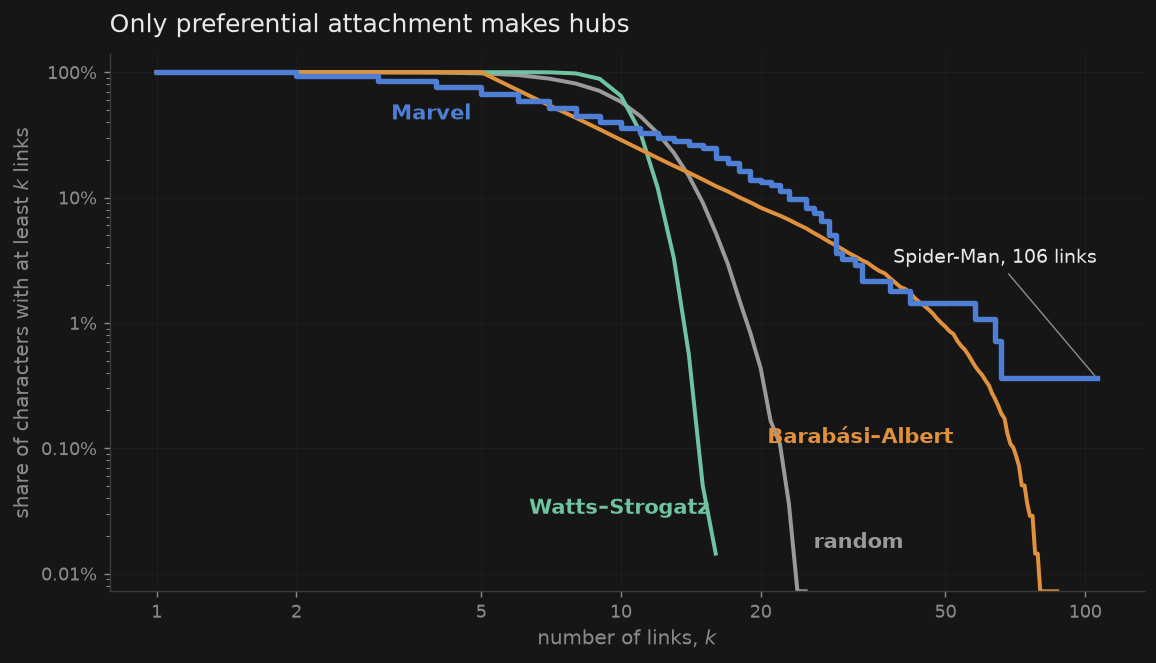

  Marvel's five biggest hubs: Spider-Man (106), Hulk (65), Wolverine (character) (63), Doctor Strange (57), Deadpool (41)
  fewer than 5 links: 33% of Marvel's characters, 0.1% of Barabási–Albert nodes (every newcomer brings 5; only the starting star's leaves can have fewer)


In [6]:
def ccdf(values):
    values = np.asarray(values)
    k = np.arange(1, values.max() + 1)
    return k, np.array([(values >= x).mean() for x in k])


def degrees(g):
    return [d for _, d in g.degree()]


pooled = {name: np.concatenate([degrees(build(s)) for s in range(RUNS)])
          for name, build in MODELS.items() if name != "shuffled Marvel"}

SHORT = {"random G(n,m)": "random", "Watts–Strogatz": "Watts–Strogatz",
         "Barabási–Albert": "Barabási–Albert", "shuffled Marvel": "shuffled Marvel"}

with plt.rc_context(DARK):
    fig, ax = plt.subplots(figsize=(9, 5.2))
    for name, vals in pooled.items():
        k, c = ccdf(vals)
        ax.plot(k, c, lw=2.2, color=COLOURS[name])
    k, c = ccdf(degrees(M))
    ax.step(k, c, where="post", lw=3, color=MARVEL_C)

    # labels sit on the curves, so the eye never has to travel to a legend
    label = dict(fontsize=11.5, fontweight="bold")
    ax.annotate("Watts–Strogatz", (15.5, 3e-4), ha="right", color=WS_C, **label)
    ax.annotate("random", (26, 1.6e-4), ha="left", color=RANDOM_C, **label)
    ax.annotate("Barabási–Albert", (52, 1.1e-3), ha="right", color=BA_C, **label)
    ax.annotate("Marvel", (3.2, .42), ha="left", color=MARVEL_C, **label)
    ax.annotate(f"Spider-Man, {real['hub']} links", (real["hub"], 1 / n), xytext=(0, 64),
                textcoords="offset points", ha="right", fontsize=10.5, color="#e8e8e8",
                arrowprops=dict(arrowstyle="-", color="#8a8a8a", lw=.8, shrinkB=2))

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xticks([1, 2, 5, 10, 20, 50, 100])
    ax.set_xticks([], minor=True)
    ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}"))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.2%}".rstrip("0").rstrip(".")
                                               if v < .01 else f"{v:.0%}"))
    ax.set_ylim(1 / (n * RUNS), 1.4)
    ax.set_xlabel("number of links, $k$", fontsize=11)
    ax.set_ylabel("share of characters with at least $k$ links", fontsize=11)
    ax.tick_params(labelsize=10)
    ax.set_title("Only preferential attachment makes hubs", fontsize=14, color="#e8e8e8",
                 loc="left", pad=12)
    style(ax)
    fig.tight_layout()
    save(fig, "fig1_degree_ccdf")
    plt.show()

top = sorted(M.degree(), key=lambda x: -x[1])[:5]
low = np.mean(np.array(degrees(M)) < NEW_LINKS)
low_ba = np.mean(pooled["Barabási–Albert"] < NEW_LINKS)     # only leaves of the starting star can
STATS.update(top_hubs=[[NAME[v], d] for v, d in top], share_below_ba_minimum=round(low, 2),
             ba_share_below_minimum=round(low_ba, 3))
print("  Marvel's five biggest hubs: " + ", ".join(f"{NAME[v]} ({d})" for v, d in top))
print(f"  fewer than {NEW_LINKS} links: {low:.0%} of Marvel's characters, {low_ba:.1%} of "
      f"Barabási–Albert nodes (every newcomer brings {NEW_LINKS}; only the starting star's leaves can have fewer)")

Random and Watts–Strogatz fall off a cliff by $k \approx 25$: their degrees crowd around the
average, and there are no hubs. Barabási–Albert is the only model whose tail runs alongside Marvel's.
It gets the *bottom* of the distribution wrong instead: every newcomer brings 5 links, so only the leaves
of the starting star can have fewer — well under 1% of its nodes — while a third of Marvel's characters do.

A tail that runs alongside Barabási–Albert is not evidence that Marvel is scale-free, or that it grew
by preferential attachment. Week 1 found a heavy tail that is not established as a power law, and many
different mechanisms produce heavy tails.

## 5. Who the random friend is

The friendship paradox says a random friend has more links than a random character. *Which*
characters are those friends? The chance that "a random friend of a random character" is $v$ can be
computed exactly: pick one of $v$'s friends $u$ as the person ($1/n$), then pick $v$ among $u$'s $k_u$
friends ($1/k_u$), summed over all of $v$'s friends:

$$P(\text{friend} = v) = \frac{1}{n} \sum_{u \in N(v)} \frac{1}{k_u}$$

Every character's fair share, as the random *person*, is $1/n = 1/277$. We also list who is never
out-popularitied — characters none of whose friends has more links than they do.

  character          links  share of friend picks  vs fair share
  Spider-Man           106                   5.8%          16.1x
  Hulk                  65                   2.8%           7.8x
  Wolverine             63                   2.5%           7.0x
  Doctor Strange        57                   2.5%           7.0x
  Deadpool              41                   2.0%           5.4x
  She-Hulk              37                   1.6%           4.5x
  Black Widow           25                   1.3%           3.6x
  Hercules              26                   1.3%           3.5x
  Cyclops               26                   1.2%           3.4x
  Deathlok              20                   1.2%           3.3x

  fair share (1 of 277 characters) = 0.36%;  the top 10 take 22% of all friend picks
  no friend with more links — giant component: ['Spider-Man'];  all 303: ['Radian (Morituri)', 'Spider-Man']
  wrote Figures/Week2/fig2_popular_friends.png


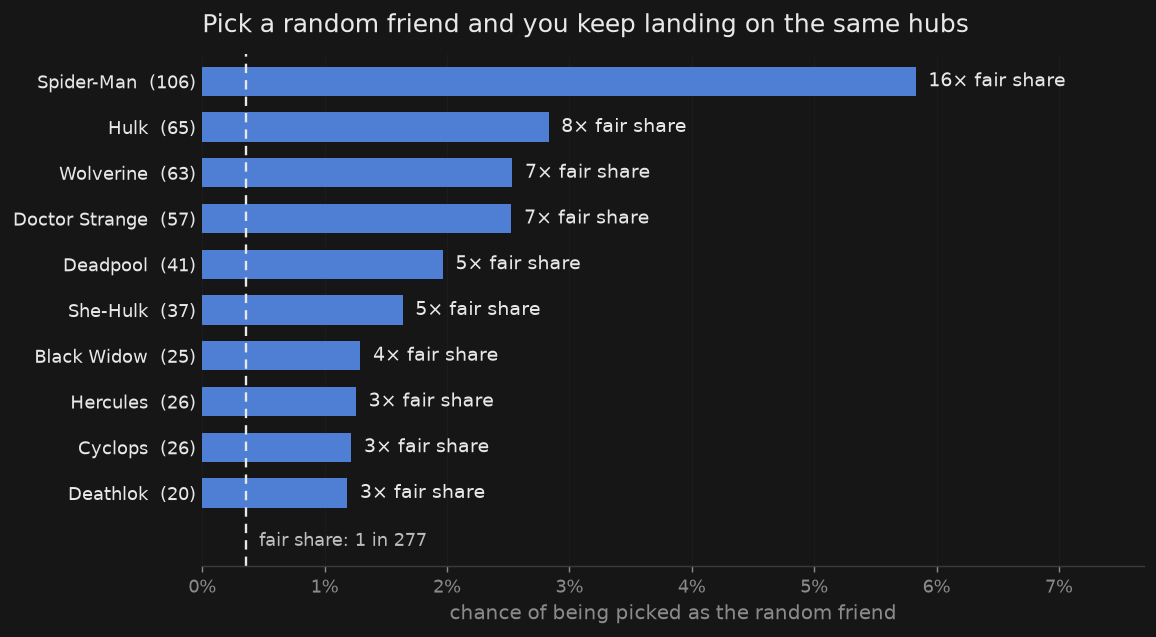

In [7]:
k = dict(M.degree())
# chance that "a random friend of a random character" is v: pick one of v's friends u as the
# person (1/n), then pick v among u's k_u friends (1/k_u) -- summed over v's friends
pick = {v: sum(1 / k[u] for u in M[v]) / n for v in M}
assert abs(sum(pick.values()) - 1) < 1e-9
top = sorted(pick, key=pick.get, reverse=True)[:10]


def never_out_popular(g):
    """Characters with at least one friend, none of whom has more links than they do."""
    return sorted(NAME[v] for v in g if g.degree(v) > 0
                  and all(g.degree(u) <= g.degree(v) for u in g[v]))


STATS.update(popular_friends=[[NAME[v].split(" (")[0], k[v], round(100 * pick[v], 1),
                               round(n * pick[v], 1)] for v in top],
             top10_friend_share=round(sum(pick[v] for v in top), 2),
             never_out_popular_giant=never_out_popular(M),
             never_out_popular_full=never_out_popular(U))

print(f"  {'character':<18}{'links':>6}{'share of friend picks':>23}{'vs fair share':>15}")
for v in top:
    print(f"  {NAME[v].split(' (')[0]:<18}{k[v]:>6}{100 * pick[v]:>22.1f}%{n * pick[v]:>14.1f}x")
print(f"\n  fair share (1 of {n} characters) = {100 / n:.2f}%;  the top 10 take "
      f"{sum(pick[v] for v in top):.0%} of all friend picks")
print(f"  no friend with more links — giant component: {never_out_popular(M)};  "
      f"all 303: {never_out_popular(U)}")

with plt.rc_context(DARK):
    fig, ax = plt.subplots(figsize=(9, 5))
    ys = np.arange(len(top))[::-1]
    ax.barh(ys, [100 * pick[v] for v in top], height=.64, color=MARVEL_C)
    ax.axvline(100 / n, color="#e8e8e8", lw=1.3, ls=(0, (4, 3)))
    for y, v in zip(ys, top):
        ax.annotate(f"{n * pick[v]:.0f}× fair share", (100 * pick[v], y), xytext=(7, 0),
                    textcoords="offset points", va="center", fontsize=10.5, color="#e8e8e8")
    ax.annotate(f"fair share: 1 in {n}", (100 / n, -1.05), xytext=(7, 0),
                textcoords="offset points", va="center", fontsize=10, color="#bdbdbd")
    ax.set_yticks(ys)
    ax.set_yticklabels([f"{NAME[v].split(' (')[0]}  ({k[v]})" for v in top], fontsize=11,
                       color="#e8e8e8")
    ax.set_ylim(-1.6, len(top) - .4)
    ax.set_xlim(0, 100 * pick[top[0]] * 1.32)
    ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}%"))
    ax.set_xlabel("chance of being picked as the random friend", fontsize=11)
    ax.tick_params(labelsize=10)
    ax.set_title("Pick a random friend and you keep landing on the same hubs", fontsize=14,
                 color="#e8e8e8", loc="left", pad=12)
    ax.grid(alpha=.3, lw=.5, axis="x")
    ax.set_axisbelow(True)
    for s in ("top", "right", "left"):
        ax.spines[s].set_visible(False)
    ax.tick_params(axis="y", length=0)
    fig.tight_layout()
    save(fig, "fig2_popular_friends")
    plt.show()

**The friends are the hubs.** Spider-Man is 1 of 277 characters but 5.8% of all random friends —
16× his fair share — and the ten most-picked characters take 22% of all picks. That over-sampling
is the whole mechanism behind the ratio of 2.43 in the table.

**Only Spider-Man is never out-popularitied** in the giant component: every other character has at
least one friend with more links. Across all 303 characters Radian would join him — the
best-connected member of week 1's nine-character island, where nobody has more than six links. Our
giant-component choice changes this particular answer, so the post says so.

## 6. The null model: what survives the shuffle?

The shuffle keeps exactly one thing — each character's degree — and scrambles everything else. So if
a property **survives** the shuffle, the degrees alone explain it. If it **dies**, it lives in *who
links to whom*.

For each measurement: the $z$-score (how many standard deviations Marvel sits from the shuffles'
mean) and the two-sided empirical $p$-value — the share of shuffles at least as far from their mean
as Marvel is, computed as $(1 + \text{count}) / (1 + 50)$ so it can never be 0. Two-sided and the
0.05 cut-off were decided before looking.

  real Marvel against 50 degree-preserving shuffles  (two-sided empirical p)

                        real          shuffles       z       p   verdict
  clustering C         0.320     0.155 ± 0.009   +18.0   0.020   dies
  distance <d>          2.67       2.60 ± 0.01    +5.2   0.020   dies
  biggest hub            106           106 ± 0       —       —   kept by construction
  friend / person       2.43       2.36 ± 0.05    +1.3   0.216   survives

  Marvel's clustering is 8.6x the random network's. Of that surplus,
  the degrees alone (the shuffle) reproduce 42%; the other 58% is in the wiring.
  smallest p that 50 shuffles can give: 1/51 = 0.020


  wrote Figures/Week2/fig3_shuffle_test.png


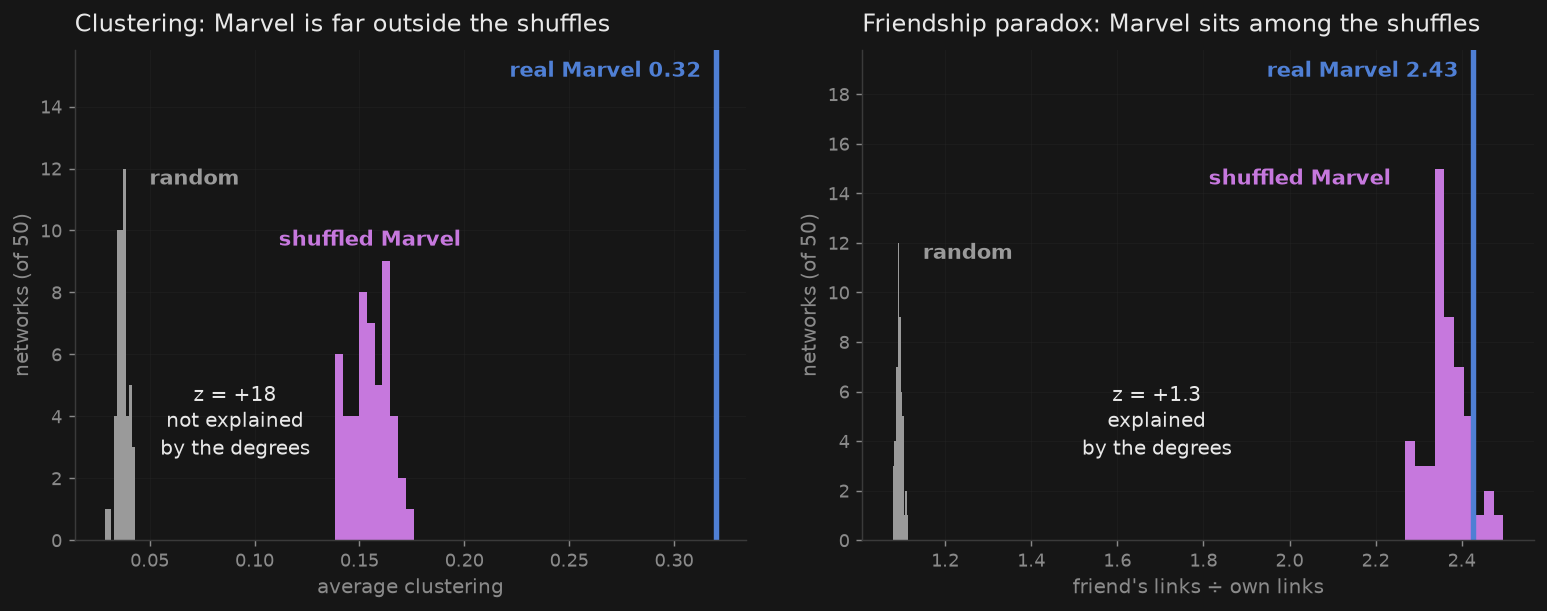

In [8]:
null = runs["shuffled Marvel"]
STATS["null"] = {}
print(f"  real Marvel against {RUNS} degree-preserving shuffles  (two-sided empirical p)\n")
print(f"  {'':<18}{'real':>8}{'shuffles':>18}{'z':>8}{'p':>8}   verdict")
for c, (label, dp) in COLS.items():
    mean, sd = null[c].mean(), null[c].std(ddof=1)
    if sd == 0:
        STATS["null"][c] = {"z": None, "p": None, "verdict": "kept by construction"}
        print(f"  {label:<18}{real[c]:>8.{dp}f}{f'{mean:.{dp}f} ± 0':>18}{'—':>8}{'—':>8}"
              f"   kept by construction")
        continue
    z = (real[c] - mean) / sd
    extreme = (np.abs(null[c] - mean) >= abs(real[c] - mean)).sum()
    pval = (1 + extreme) / (1 + RUNS)
    verdict = "survives" if pval >= .05 else "dies"
    STATS["null"][c] = {"z": round(z, 1), "p": round(pval, 3), "verdict": verdict}
    print(f"  {label:<18}{real[c]:>8.{dp}f}{f'{mean:.{dp}f} ± {sd:.{dp}f}':>18}{z:>+8.1f}"
          f"{pval:>8.3f}   {verdict}")

C_random = runs["random G(n,m)"]["C"].mean()
from_degrees = (null["C"].mean() - C_random) / (real["C"] - C_random)
STATS.update(clustering_vs_random=round(real["C"] / C_random, 1),
             clustering_surplus_from_degrees=round(from_degrees, 2),
             distance_gap_to_shuffle=round(real["d"] - null["d"].mean(), 2))
print(f"\n  Marvel's clustering is {real['C'] / C_random:.1f}x the random network's. Of that surplus,")
print(f"  the degrees alone (the shuffle) reproduce {from_degrees:.0%}; the other "
      f"{1 - from_degrees:.0%} is in the wiring.")
print(f"  smallest p that {RUNS} shuffles can give: 1/{RUNS + 1} = {1 / (RUNS + 1):.3f}")

PANELS = [("C", "Clustering: Marvel is far outside the shuffles", "average clustering",
           f"z = +{STATS['null']['C']['z']:.0f}\nnot explained\nby the degrees"),
          ("paradox", "Friendship paradox: Marvel sits among the shuffles",
           "friend's links ÷ own links",
           f"z = +{STATS['null']['paradox']['z']:.1f}\nexplained\nby the degrees")]

with plt.rc_context(DARK):
    fig, axs = plt.subplots(1, 2, figsize=(12, 4.8))
    for ax, (c, title, xlabel, verdict) in zip(axs, PANELS):
        peak = 0
        for name in ("random G(n,m)", "shuffled Marvel"):
            vals = runs[name][c]
            counts, _, _ = ax.hist(vals, bins=10, color=COLOURS[name])
            peak = max(peak, counts.max())
            # label beside its own bars: random on its right; the shuffle above its peak when
            # the Marvel line is clear of it, otherwise on its left so the line stays readable
            if name == "random G(n,m)":
                xy, off, ha, va = (vals.max(), counts.max()), (8, 0), "left", "top"
            elif real[c] > vals.max():
                xy, off, ha, va = (vals.mean(), counts.max()), (0, 6), "center", "bottom"
            else:
                xy, off, ha, va = (vals.min(), counts.max()), (-8, 0), "right", "top"
            ax.annotate(SHORT[name], xy, xytext=off, textcoords="offset points", ha=ha, va=va,
                        fontsize=11.5, fontweight="bold", color=COLOURS[name])
        ax.axvline(real[c], color=MARVEL_C, lw=3)
        ax.set_ylim(0, peak * 1.32)
        ax.yaxis.set_major_locator(MaxNLocator(integer=True))
        ax.annotate(f"real Marvel {real[c]:.2f}", (real[c], peak * 1.29), xytext=(-8, 0),
                    textcoords="offset points", ha="right", va="top", fontsize=11.5,
                    fontweight="bold", color=MARVEL_C)
        gap_x = (runs["random G(n,m)"][c].max() + null[c].min()) / 2
        ax.text(gap_x, peak * .32, verdict, ha="center", va="center", fontsize=11,
                color="#e8e8e8", linespacing=1.4)
        ax.set_xlabel(xlabel, fontsize=11)
        ax.set_ylabel(f"networks (of {RUNS})", fontsize=11)
        ax.tick_params(labelsize=10)
        ax.set_title(title, fontsize=13.5, color="#e8e8e8", loc="left", pad=10)
        style(ax)
    fig.tight_layout(w_pad=3)
    save(fig, "fig3_shuffle_test")
    plt.show()

- **Clustering dies** ($z = +18$). Shuffled Marvel has 0.155 — four times a random network, because
  hubs have so many neighbour pairs that some close by chance — but only half the real 0.320. Of
  Marvel's clustering surplus over a random network, the degrees reproduce 42%; the other 58% is in
  the wiring. Our best guess is that articles about characters who share a team or a storyline link
  to each other, but the shuffle only tells us the triangles are not the degrees — not what they are.
  (Communities are week 4.)
- **The friendship paradox survives** ($z = +1.3$, $p = 0.22$). A character with 106 links is
  somebody's friend 106 times however the links are arranged, so keeping the degrees keeps the
  paradox.
- **The biggest hub is kept by construction.** The shuffles' spread is zero, so there is nothing to
  test.
- **Distance: statistically different, practically not.** Marvel's paths are 0.07 hops *longer* than
  the shuffles' (2.67 vs 2.60, $z = +5.2$). The direction makes sense — links spent closing triangles
  are links not spent on shortcuts — but 0.07 hops is not a finding worth leaning on.
- $p = 0.020$ is also the smallest value 50 shuffles can give, so for clustering and distance the
  $z$-score is what carries the strength of the evidence.

## 7. What we found

**Marvel is a small world.** 8.6× the clustering of a random network with the same size, at the same
average distance (2.67 vs 2.66).

**No model gets all four measurements.** The random network gets distance and nothing else.
Watts–Strogatz gets clustering — because we tuned it to — but has no hubs and almost no friendship
paradox. Barabási–Albert is the only model that grows hubs and a real paradox, and it misses
clustering by a factor of three and has almost no characters with fewer than five links.

**The paradox is in the degrees; the triangles are in the wiring.** Keep every character's degree and
scramble the links: the friendship paradox survives untouched, but clustering halves. 42% of Marvel's
clustering surplus comes from its degree sequence, and 58% from who links to whom. The random friends
are the hubs: Spider-Man alone is 5.8% of them, 16× his fair share.

**What surprised us.** The random network gets the distance exactly right. "Six degrees" is the
famous property of real networks, and chance produces it for free — short paths are not evidence of
anything special. And Watts–Strogatz, the model built to explain real networks, has almost no
friendship paradox, because every node starts with the same ten neighbours.

**Choices we made.**

- *Undirected giant component (277 of 303).* Distance is undefined across components, and all the
  models are undirected. Directed or full-network results would differ.
- *$G(n,m)$, not $G(n,p)$.* The same link count in every run.
- *Watts–Strogatz $k = 10$, $q = 0.2$.* The small-world range 0.001–0.1 leaves clustering at 0.49–0.66;
  $q = 0.2$ matches Marvel, which makes clustering a fitted number rather than a test for this model.
- *Barabási–Albert with 5 links per newcomer.* 1,360 links, 4% fewer than Marvel; 6 would be 14% too
  many.
- *Edge swaps, not the configuration model.* Swaps keep every degree exactly.
- *50 networks per model; two-sided empirical $p$ with a 0.05 cut-off.*
- *The friendship paradox as an exact ratio.* No sampling noise, and comparable across models whose
  average degrees differ slightly.

**What we cannot conclude.** That Marvel grew by preferential attachment (matching a tail is not
observing a mechanism); that its degrees follow a power law (week 1); or *why* its links close into
triangles (the shuffle rules out the degrees, nothing more).

## 8. Every number, pinned

`stats.json` is the single source for the post. The regression check pins the numbers that come from
the data alone, so a change in the snapshot or the loading fails loudly instead of leaving stale prose
on the site. Model numbers are not pinned: they depend on the random seeds (0–49) and on the networkx
version.

In [9]:
Path("stats.json").write_text(json.dumps(STATS, indent=2, ensure_ascii=False))
print(f"  wrote stats.json — {len(STATS)} entries, the single source for every number in the post")

# Regression harness: the numbers that come from the data alone, pinned. If the snapshot or
# the loading changes, this fails loudly instead of leaving stale prose on the site.
EXPECTED = {("n",): 277, ("m",): 1421, ("mean_degree",): 10.26, ("left_out",): 26,
            ("marvel", "C"): 0.32, ("marvel", "d"): 2.67, ("marvel", "hub"): 106,
            ("marvel", "paradox"): 2.43, ("share_below_ba_minimum",): 0.33,
            ("never_out_popular_giant",): ["Spider-Man"], ("degrees", "friend_formula"): 22.25,
            ("clustering_example", "spiderman_linked"): 462}


def get(keys):
    value = STATS
    for key in keys:
        value = value[key]
    return value


print("\n  regression check")
bad = [k for k, want in EXPECTED.items() if get(k) != want]
for k, want in EXPECTED.items():
    print(f"    {'.'.join(k):<18}{str(get(k)):>8}   expected {str(want):>8}   "
          f"{'ok' if get(k) == want else 'MISMATCH'}")
assert not bad, f"stats drifted: {bad}"

  wrote stats.json — 24 entries, the single source for every number in the post

  regression check
    n                      277   expected      277   ok
    m                     1421   expected     1421   ok
    mean_degree          10.26   expected    10.26   ok
    left_out                26   expected       26   ok
    marvel.C              0.32   expected     0.32   ok
    marvel.d              2.67   expected     2.67   ok
    marvel.hub             106   expected      106   ok
    marvel.paradox        2.43   expected     2.43   ok
    share_below_ba_minimum    0.33   expected     0.33   ok
    never_out_popular_giant['Spider-Man']   expected ['Spider-Man']   ok
    degrees.friend_formula   22.25   expected    22.25   ok
    clustering_example.spiderman_linked     462   expected      462   ok
